<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import os

from scipy.stats import chi2

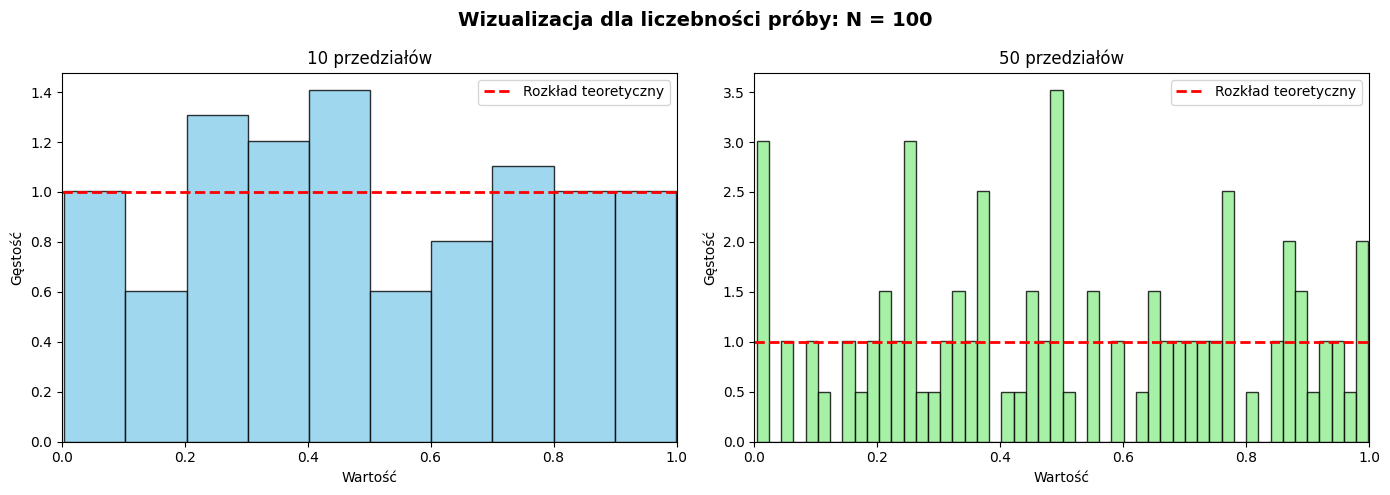

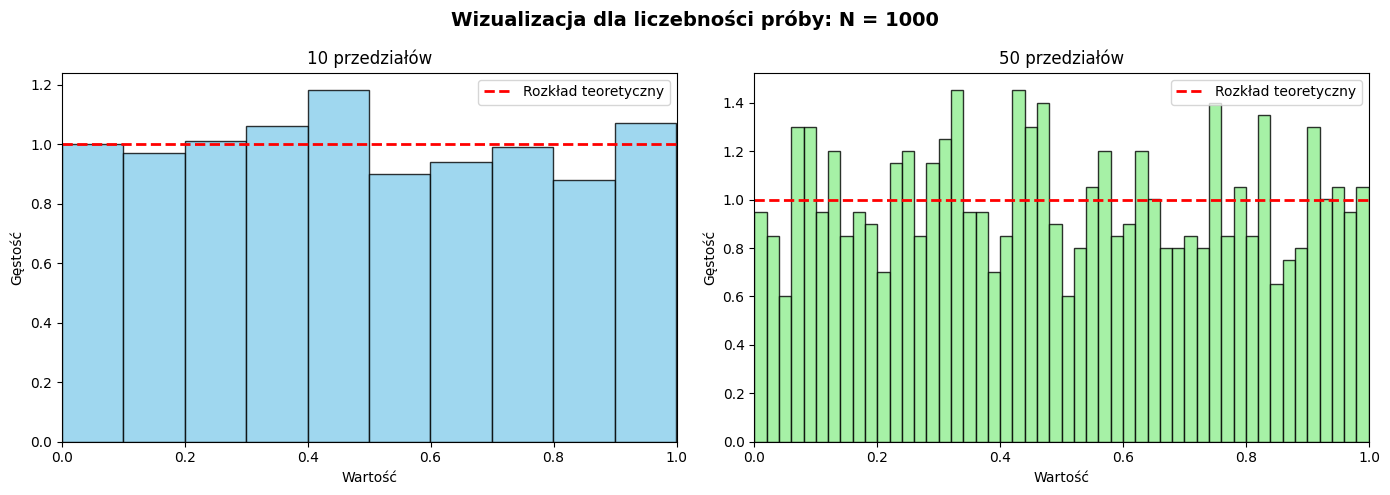

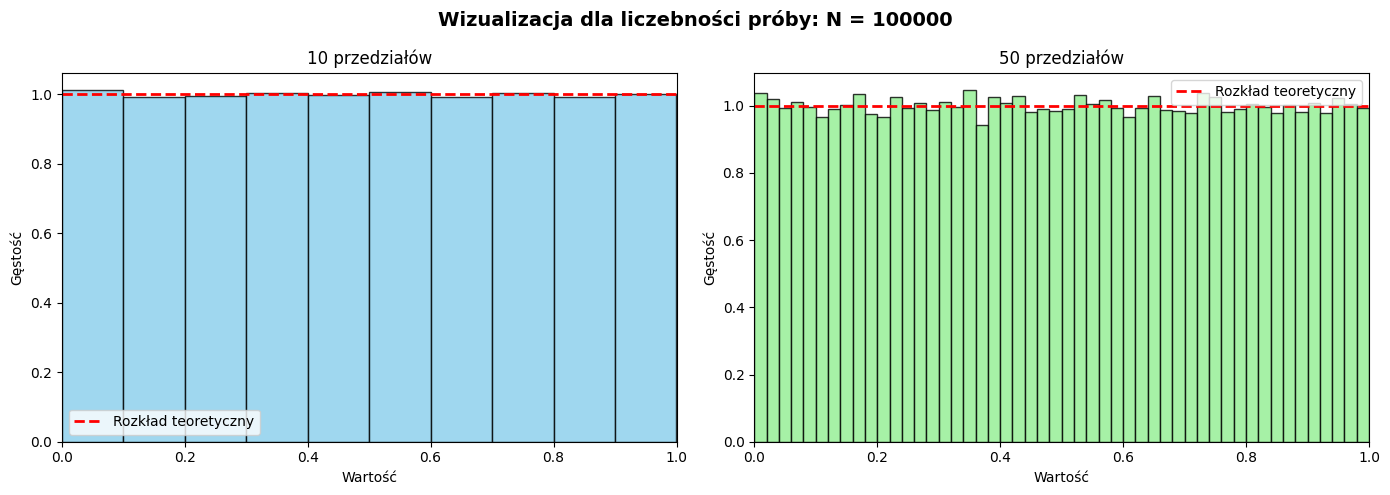

In [32]:
# Konfiguracja: różne wielkości prób, aby zaobserwować wpływ liczebności
wielkosci_prob = [100, 1000, 100000]
nazwa_pliku_prefix = "liczby_losowe_"

for N in wielkosci_prob:
    nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"
    # 1. Generacja liczb z rozkładu równomiernego (od 0 do 1)
    # Odpowiednik generatora z GSL / std::random w C++
    liczby = np.random.uniform(0, 1, N)

    # 2. Zapis wygenerowanych liczb do pliku tekstowego
    np.savetxt(nazwa_pliku, liczby)

    # 3. Odczyt wygenerowanych liczb z pliku tekstowego
    liczby_z_pliku = np.loadtxt(nazwa_pliku)

    # 4. Wykreślenie histogramów
    # Używamy density=True, aby znormalizować pole pod histogramem do 1,
    # co pozwala łatwo nanieść rozkład teoretyczny (dla U(0,1) y=1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}", fontsize=14, fontweight='bold')

    # Rozkład teoretyczny (linia pozioma na wysokości 1)
    teoretyczny_x = [0, 1]
    teoretyczny_y = [1, 1]

    # Histogram 1 - 10 przedziałów (bins=10)
    axs[0].hist(liczby_z_pliku, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.8)
    axs[0].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[0].set_title('10 przedziałów')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość')
    axs[0].set_xlim(0, 1)
    axs[0].legend()

    # Histogram 2 - 50 przedziałów (bins=50)
    axs[1].hist(liczby_z_pliku, bins=50, density=True, color='lightgreen', edgecolor='black', alpha=0.8)
    axs[1].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[1].set_title('50 przedziałów')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Gęstość')
    axs[1].set_xlim(0, 1)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

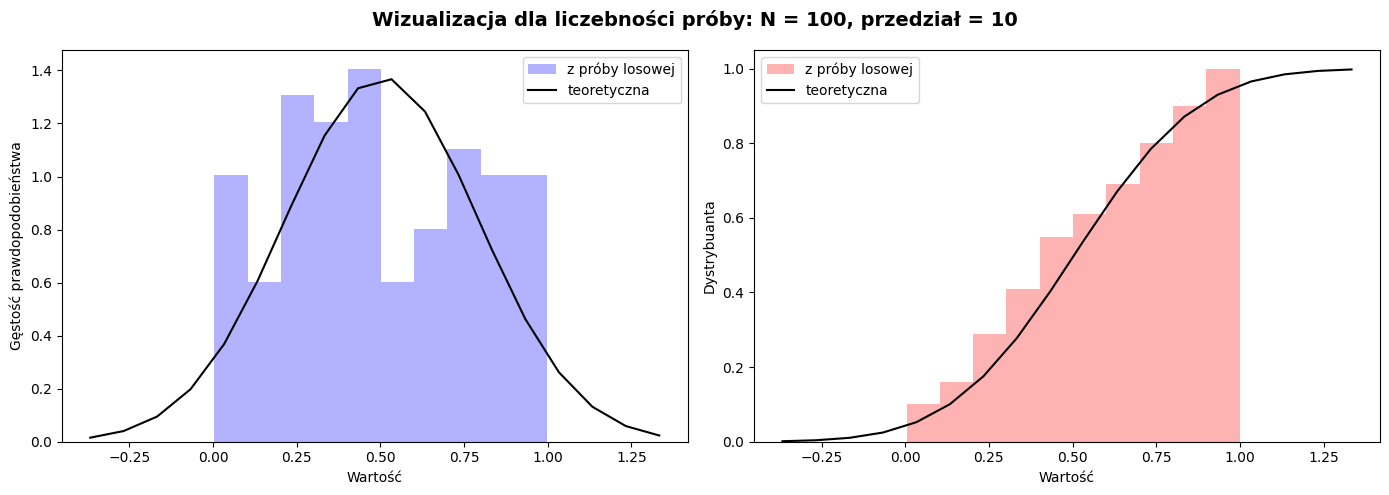

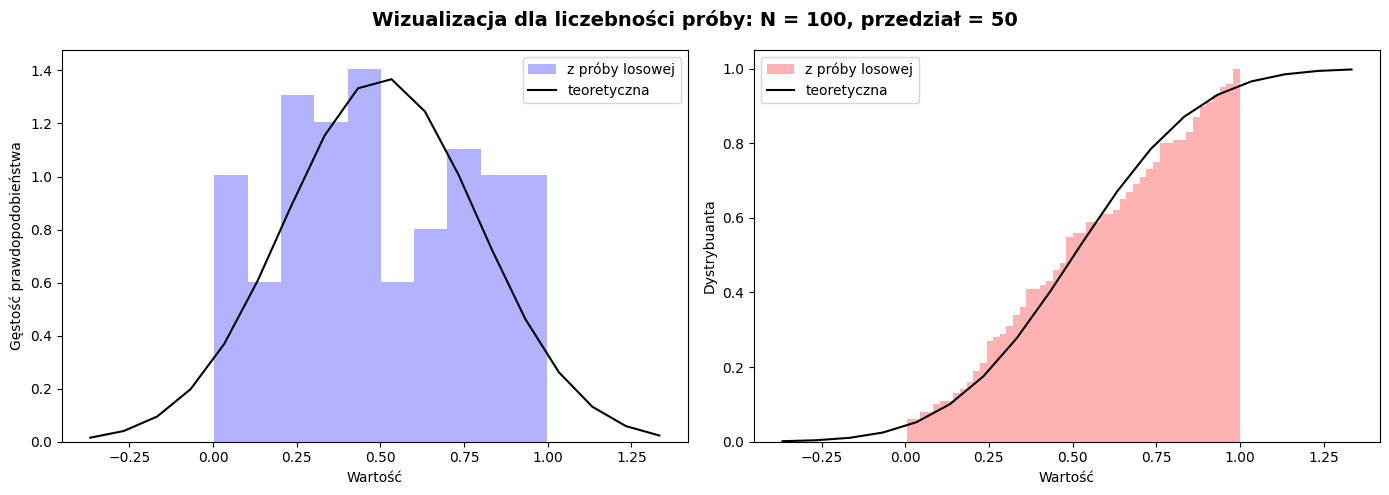

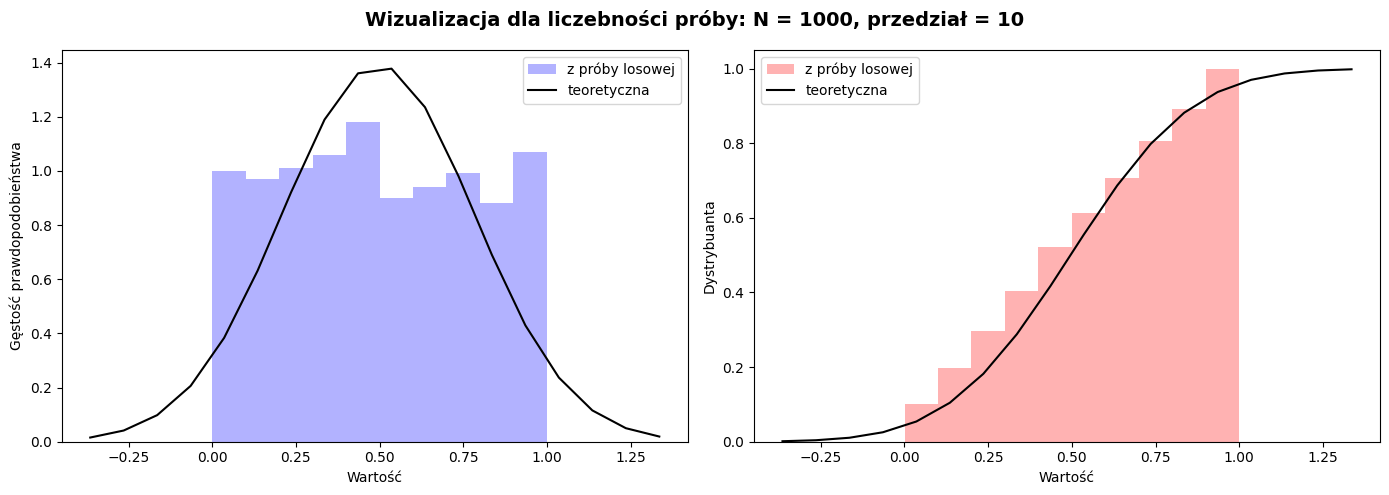

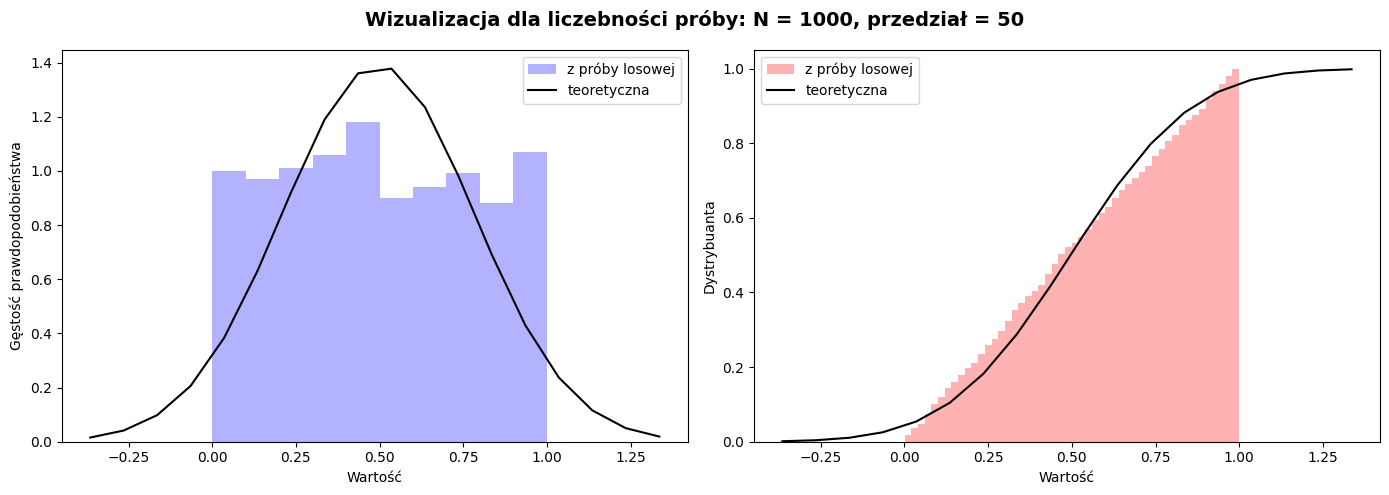

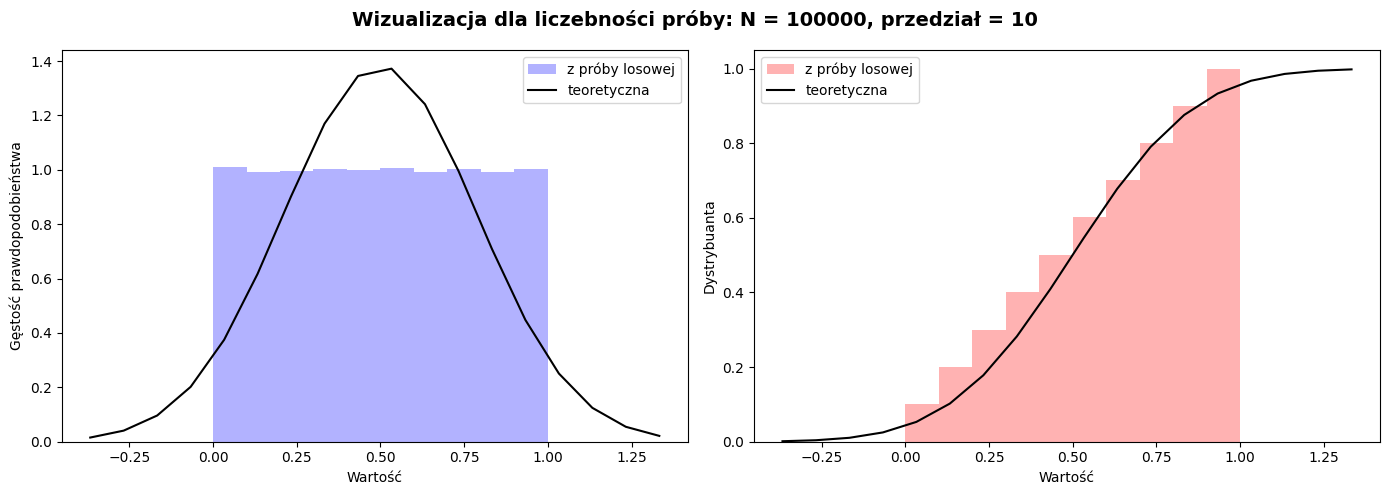

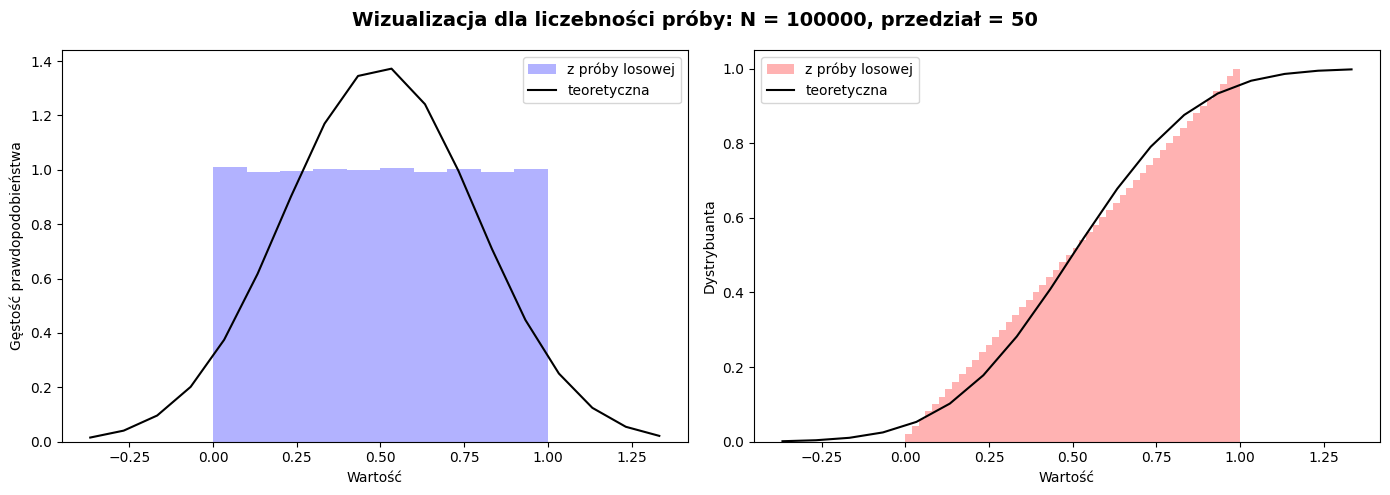

In [35]:
os.makedirs('./wykresy/', exist_ok=True)

for N in wielkosci_prob:
  nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"

  dane = np.loadtxt(nazwa_pliku, unpack=True)

  # Wartości teoretyczne wartości oczekiwanej i odchylenia standardowego.
  wart_oczek = np.mean(dane)
  odch_std   = np.std(dane, ddof=1)

  # Wartości na osi X histogramu.
  dziedzina = np.arange(wart_oczek-3*odch_std, wart_oczek+3*odch_std, 0.1)
  # Teoretyczna funkcja gęstości prawdopodobieństwa rozkładu normalnego o zadanych parametrach.
  fgp = norm.pdf(dziedzina, wart_oczek, odch_std)
  # Rysujemy histogram częstości. Histogram liczebności uzyskalibyśmy przy 'normed=False'.
  # W nowszej wersji NumPy zamiast 'normed' używamy parametru 'density'.
  for bin in [10, 50]:
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}, przedział = {bin}", fontsize=14, fontweight='bold')

    axs[0].hist(dane, density=True, color='blue', alpha=0.3, label='z próby losowej')
    # Rysujemy również teoretyczną funkcję gęstości prawodpodobieństwa.
    axs[0].plot(dziedzina, fgp, 'k-', label='teoretyczna')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość prawdopodobieństwa')
    axs[0].legend(loc='best')

    # Create the directory if it doesn't exist

    # Teoretyczna dystrybuanta rozkładu normalnego o zadanych parametrach.
    dystrybuanta = norm.cdf(dziedzina, wart_oczek, odch_std)
    # Dystrybuanta empiryczna, czyli histogram skumulowany ('cumulative=True').
    # Tym razem wymusiliśmy liczbę przedziałów 'bins'.
    axs[1].hist(dane, bins=bin, density=True, color='red', alpha=0.3, cumulative=True, label='z próby losowej')
    axs[1].plot(dziedzina, dystrybuanta, 'k-', label='teoretyczna')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Dystrybuanta')
    axs[1].legend(loc='best')
    fig.savefig(f"./wykresy/histogram_dystrybuanta_liczba_próbek_{N}_przedział_{bin}.pdf", format='pdf')

    plt.tight_layout()
    plt.show()

In [34]:
def generator_zly_randu(n_samples, seed=12345):
    """
    Implementacja 'złego' generatora typu LCG (Linear Congruential Generator).
    Używamy klasycznych parametrów dla generatora RANDU (a=65539, c=0, m=2**31).
    Zwraca wartości znormalizowane do przedziału [0, 1).
    """
    a = 65539
    c = 0
    m = 2**31
    X = seed

    # Tworzymy pustą tablicę na wyniki
    results = np.zeros(n_samples)

    for i in range(n_samples):
        X = (a * X + c) % m
        results[i] = X / m

    return results

def test_chi_kwadrat(dane, k):
    """
    Oblicza statystykę chi-kwadrat ze wzoru uproszczonego oraz p-wartość.
    """
    n = len(dane)

    # Zliczamy ile liczb wpadło do każdego z k przedziałów w zakresie [0, 1]
    n_i, _ = np.histogram(dane, bins=k, range=(0.0, 1.0))

    # Implementacja uproszczonego wzoru z zadania: (k / n) * sum(n_i**2) - n
    chi_kwadrat_stat = (k / n) * np.sum(n_i**2) - n

    # Obliczamy liczbę stopni swobody
    df = k - 1

    # Obliczamy p-wartość.
    # scipy.stats.chi2.sf to "survival function" (1 - dystrybuanta CDF),
    # co pozwala uzyskać pole pod prawym ogonem rozkładu.
    p_wartosc = chi2.sf(chi_kwadrat_stat, df)

    return chi_kwadrat_stat, p_wartosc

# ==========================================
# GŁÓWNA CZĘŚĆ PROGRAMU
# ==========================================

n_losowan = 100000  # Liczebność próby losowej
przedzialy_k = [11, 51, 101] # Badane wartości k z zadania
for N in wielkosci_prob:
  nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"

  dane = np.loadtxt(nazwa_pliku, unpack=True)

  print(f"Generowanie {N} liczb...")
  # 'Dobry' generator: standardowy generator liczb pseudolosowych z NumPy
  dane_dobre = dane
  # 'Zły' generator: nasza implementacja RANDU
  dane_zle = generator_zly_randu(len(dane))
  # for nazwa_pliku in []
  for k in przedzialy_k:
      print(f"\n{'-'*40}")
      print(f"Wyniki testu dla k = {k} przedziałów:")
      print(f"{'-'*40}")

      # 1. Test dobrego generatora
      stat_dobry, p_dobry = test_chi_kwadrat(dane_dobre, k)
      wynik_dobry = "ZGODNY z rozkładem U(0,1)" if p_dobry >= 0.05 else "NIEZGODNY (odrzucamy hipotezę)"

      print("Generator DOBRY (NumPy):")
      print(f"  Wartość Chi-kwadrat: {stat_dobry:.4f}")
      print(f"  P-wartość:           {p_dobry:.6f}")
      print(f"  Werdykt (p >= 0.05): {wynik_dobry}\n")

      # 2. Test złego generatora
      stat_zly, p_zly = test_chi_kwadrat(dane_zle, k)
      wynik_zly = "ZGODNY z rozkładem U(0,1)" if p_zly >= 0.05 else "NIEZGODNY (odrzucamy hipotezę)"

      print("Generator ZŁY (RANDU):")
      print(f"  Wartość Chi-kwadrat: {stat_zly:.4f}")
      print(f"  P-wartość:           {p_zly:.6f}")
      print(f"  Werdykt (p >= 0.05): {wynik_zly}")

Generowanie 100 liczb...

----------------------------------------
Wyniki testu dla k = 11 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 6.0400
  P-wartość:           0.811891
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 4.5000
  P-wartość:           0.921986
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

----------------------------------------
Wyniki testu dla k = 51 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 58.1000
  P-wartość:           0.201618
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 45.8600
  P-wartość:           0.640132
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

----------------------------------------
Wyniki testu dla k = 101 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 106.0400
  P-wartość: 